# Heart Disease Data Analysis

## 1. Data Recognising

### 1.1. Dataset Background

This dataset contains 303 patient medical examination records and includes 14 core attributes (13 features and 1 target variable), which are used to analyze whether a patient has heart disease.




In [2]:
import pandas as pd
import numpy as np

# 读取数据
# 数据集中使用 ? 表示缺失值
df = pd.read_csv(
    r"C:\Users\23311\Desktop\heart_disease.csv",
    na_values="?"
)

# 查看前6行数据
print(df.head(6))

# 查看数据基本信息
print(df.info())

# 查看数据维度
print(df.shape)

# 查看缺失值数量
print(df.isnull().sum())


   Unnamed: 0   age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  \
0           0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0   
1           1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0   
2           2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0   
3           3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0   
4           4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0   
5           5  56.0  1.0  2.0     120.0  236.0  0.0      0.0    178.0    0.0   

   oldpeak  slope   ca  thal  num  
0      2.3    3.0  0.0   6.0    0  
1      1.5    2.0  3.0   3.0    2  
2      2.6    2.0  2.0   7.0    1  
3      3.5    3.0  0.0   3.0    0  
4      1.4    1.0  0.0   3.0    0  
5      0.8    1.0  0.0   3.0    0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  


### 1.2. Feature Description

The dataset contains 14 core attributes, including 13 input features and 1 target variable.
The medical meanings of each feature are described in the following table.

In [3]:
feature_info = pd.DataFrame({
    "Feature Name": [
        "age", "sex", "cp", "trestbps", "chol",
        "fbs", "restecg", "thalach", "exang",
        "oldpeak", "slope", "ca", "thal", "num"
    ],

    "Attribute Type": [
        "Continuous", "Categorical", "Categorical", "Continuous", "Continuous",
        "Categorical", "Categorical", "Continuous", "Categorical",
        "Continuous", "Categorical", "Categorical", "Categorical", "Target"
    ],

    "Medical Description": [
        "Age of the patient (years)",
        "Sex (1 = male; 0 = female)",
        "Chest pain type (1: typical angina; 2: atypical angina; 3: non-anginal pain; 4: asymptomatic)",
        "Resting blood pressure (mmHg)",
        "Serum cholesterol level (mg/dl)",
        "Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)",
        "Resting electrocardiographic results",
        "Maximum heart rate achieved",
        "Exercise-induced angina (1 = yes; 0 = no)",
        "ST depression induced by exercise relative to rest",
        "Slope of the peak exercise ST segment",
        "Number of major vessels colored by fluoroscopy (0-3)",
        "Thalassemia / myocardial perfusion imaging result",
        "Heart disease diagnosis (0 = no disease; 1-4 = increasing severity)"
    ]
})

from IPython.display import display

# 显示完整列内容
pd.set_option('display.max_colwidth', None)

display(feature_info)



,Feature Name,Attribute Type,Medical Description
0,age,Continuous,Age of the patient (years)
1,sex,Categorical,Sex (1 = male; 0 = female)
2,cp,Categorical,Chest pain type (1: typical angina; 2: atypical angina; 3: non-anginal pain; 4: asymptomatic)
3,trestbps,Continuous,Resting blood pressure (mmHg)
4,chol,Continuous,Serum cholesterol level (mg/dl)
5,fbs,Categorical,Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
6,restecg,Categorical,Resting electrocardiographic results
7,thalach,Continuous,Maximum heart rate achieved
8,exang,Categorical,Exercise-induced angina (1 = yes; 0 = no)
9,oldpeak,Continuous,ST depression induced by exercise relative to rest


## 2. Data Pre-processing

### 2.1 MCAR Test and Missing Data Handling Strategy

If the null hypothesis (H0) of Little’s MCAR test is **rejected (p < 0.05)**, the missing data mechanism is considered **not completely at random (i.e., MAR or MNAR)**. In this case, simple imputation methods such as mean or median substitution are not appropriate, as they may introduce bias and distort the underlying data distribution.

Therefore, this study applies **Multiple Imputation by Chained Equations (MICE)** under the assumption of Missing at Random (MAR). MICE performs iterative, variable-wise imputation, where each incomplete variable is modeled conditional on all other variables in the dataset.

Different imputation models are applied depending on variable type:

- **Continuous variables**: Linear regression
- **Binary categorical variables**: Logistic regression
- **Multicategorical variables**: Multinomial logistic regression

This strategy ensures that:
- Imputed values remain within plausible ranges of the original data
- The structural constraints of categorical variables are preserved
- Uncertainty due to missingness is appropriately incorporated into the analysis

---

#### Little’s MCAR Test

In [4]:
import pandas as pd
import numpy as np
from pyampute.exploration.mcar_statistical_tests import MCARTest

# Load dataset (replace with your actual path)


# Select variables included in the MCAR test
# These are all relevant clinical and demographic features
test_vars = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal"
]

# Extract subset for MCAR testing
X = df[test_vars].copy()

# Initialize Little's MCAR test (pyampute implementation)
mcar_test = MCARTest(method="little")

# -----------------------------
# Data preprocessing for MCAR test
# -----------------------------
# Convert categorical variables into numeric codes
# Missing categories are encoded as NaN
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = pd.Categorical(X[col]).codes
        X.loc[X[col] < 0, col] = np.nan

# Ensure all variables are numeric (required by MCAR test)
X = X.astype(float)

# -----------------------------
# Run Little's MCAR test
# -----------------------------
try:
    result = mcar_test.little_mcar_test(X)

    # Handle different possible return formats
    if isinstance(result, dict):
        p_value = result.get("p_value", list(result.values())[-1])
    else:
        p_value = float(result)

    print("Little's MCAR test p-value:", p_value)

    # Interpretation of hypothesis test
    if p_value >= 0.05:
        print("Conclusion: Data is likely MCAR (fail to reject H0)")
    else:
        print("Conclusion: MCAR is rejected (data is likely MAR or MNAR)")

except Exception as e:
    print("MCAR test failed:", e)

Little's MCAR test p-value: 0.8719554791532151
Conclusion: Data is likely MCAR (fail to reject H0)


---
#### Implementation

In [5]:
# -----------------------------------
# Missing Value Imputation
# -----------------------------------

# Extract feature groups from feature_info
continuous_cols = feature_info.loc[
    feature_info["Attribute Type"] == "Continuous",
    "Feature Name"
].tolist()

categorical_cols = feature_info.loc[
    feature_info["Attribute Type"] == "Categorical",
    "Feature Name"
].tolist()

# Mean imputation for continuous variables
for col in continuous_cols:
    df[col] = df[col].fillna(df[col].mean())

# Mode imputation for categorical variables
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify that all missing values have been handled
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
num           0
dtype: int64


### 2.2 Feature Transformation and Encoding

To improve model stability and satisfy the assumptions of statistical learning algorithms, feature transformation and encoding procedures were applied separately to continuous and categorical variables.

#### Continuous Feature Processing

The distributions of continuous variables were first examined using histograms and Q-Q plots to evaluate normality and skewness characteristics.

- Features that approximately followed a normal distribution were directly standardized using Z-score normalization.
- Features exhibiting significant positive skewness (e.g., `chol` and `oldpeak`) were first transformed using logarithmic transformation (`log1p`) to reduce skewness and stabilize variance, followed by Z-score standardization.

This procedure improves numerical comparability among variables and reduces the influence of extreme values.

#### Categorical Feature Processing

For unordered multicategorical variables such as `cp`, `restecg`, and `thal`, One-Hot Encoding was applied to convert categorical labels into binary indicator variables.

This prevents machine learning models from incorrectly interpreting categorical levels as ordinal or continuous numerical values.


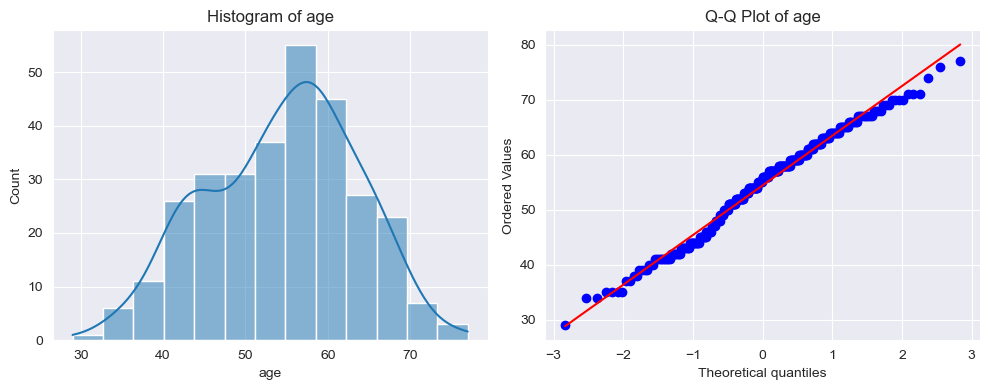

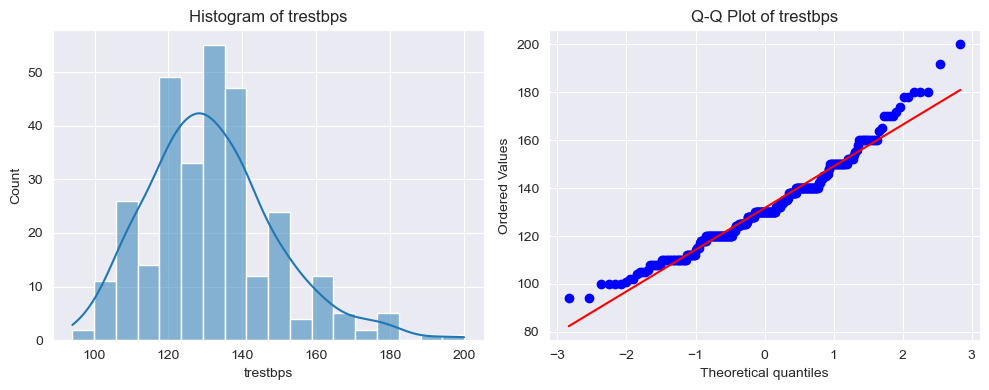

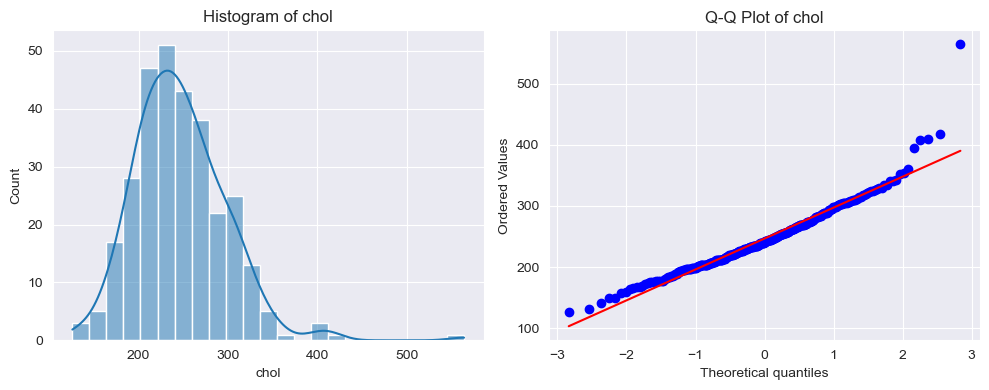

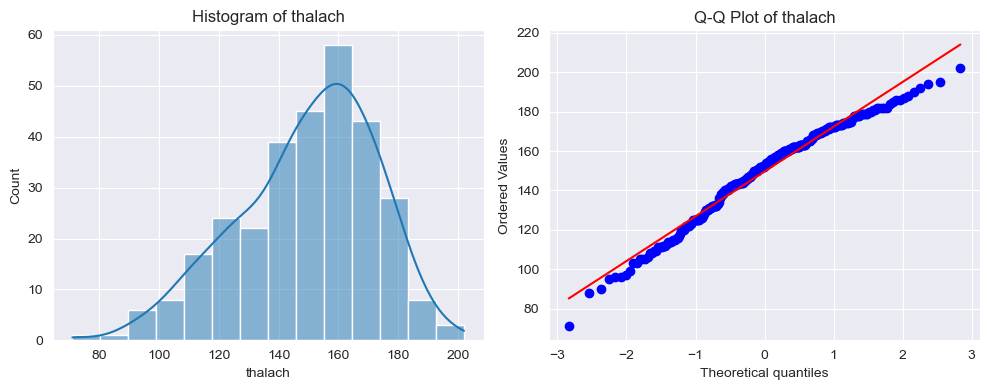

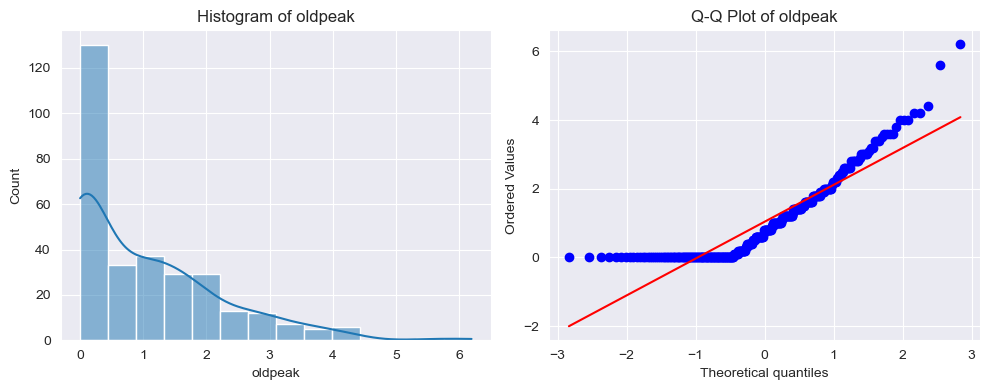

In [6]:
# -----------------------------------
# Continuous Feature Distribution Analysis
# -----------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Extract continuous variables
continuous_cols = feature_info.loc[
    feature_info["Attribute Type"] == "Continuous",
    "Feature Name"
].tolist()

# Plot histogram and Q-Q plot for each continuous variable
for col in continuous_cols:

    plt.figure(figsize=(10, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")

    # Q-Q Plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")

    plt.tight_layout()
    plt.show()

The distribution analysis showed that most continuous variables approximately followed a symmetric distribution. However, the `oldpeak` feature exhibited substantial positive skewness, with observations heavily concentrated between 0 and 1 and a long right tail.

Therefore, logarithmic transformation (`log1p`) was applied to `oldpeak` prior to standardization in order to reduce skewness and stabilize variance.

In [7]:
# -----------------------------------
# Log Transformation for Positively Skewed Features
# -----------------------------------

# Features identified as positively skewed
skewed_cols = ["oldpeak"]

# Apply log transformation
for col in skewed_cols:
    df[col] = np.log1p(df[col])

# -----------------------------------
# Z-score Standardization
# -----------------------------------

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Apply standardization to continuous variables
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

# Preview transformed data
df[continuous_cols].head()


import joblib

joblib.dump(scaler, "scaler.pkl")



print("Scaler and feature lists exported successfully!")

Scaler and feature lists exported successfully!


In [8]:
# -----------------------------------
# One-Hot Encoding for Categorical Variables
# -----------------------------------

# Multicategorical variables requiring one-hot encoding
multi_categorical_cols = ["cp", "restecg", "thal"]

# Apply one-hot encoding
df = pd.get_dummies(
    df,
    columns=multi_categorical_cols,
    drop_first=True
)


In [12]:
# Delete Unnamed

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Change bool to int for training
df = df.astype({col: int for col in df.select_dtypes(include=["bool"]).columns})

# Display transformed dataset
print(df.head())
print(df.shape)



        age  sex  trestbps      chol  fbs   thalach  exang   oldpeak  slope  \
0  0.948726  1.0  0.757525 -0.264900  1.0  0.017197    0.0  1.192005    3.0   
1  1.392002  1.0  1.611220  0.760415  0.0 -1.821905    1.0  0.661637    2.0   
2  1.392002  1.0 -0.665300 -0.342283  0.0 -0.902354    1.0  1.358226    2.0   
3 -1.932564  1.0 -0.096170  0.063974  0.0  1.637359    0.0  1.784504    3.0   
4 -1.489288  0.0 -0.096170 -0.825922  0.0  0.980537    0.0  0.583653    1.0   

    ca  num  cp_2.0  cp_3.0  cp_4.0  restecg_1.0  restecg_2.0  thal_6.0  \
0  0.0    0       0       0       0            0            1         1   
1  3.0    2       0       0       1            0            1         0   
2  2.0    1       0       0       1            0            1         0   
3  0.0    0       0       1       0            0            0         0   
4  0.0    0       1       0       0            0            1         0   

   thal_7.0  
0         0  
1         0  
2         1  
3         0  
4   

### 3. Model Construction Strategy

After completing data preprocessing, the dataset was split into training and testing sets (typically 70:30) to evaluate model generalization performance.

Two modeling tasks were designed according to the nature of the target variable:

#### Task 1: Binary Classification (Disease Presence)

The original target variable was transformed into a binary outcome, where:

- 0 indicates no heart disease
- 1–4 indicates presence of heart disease

A **Logistic Regression model** was applied for this task. The model parameters were estimated using the **Iteratively Reweighted Least Squares (IRLS)** algorithm.

One additional point to note is that before training, we first check if the data is balanced. If it is not, we use SMOTE to handle the imbalance.

#### Task 2: Ordinal Multiclass Classification (Disease Severity)

The original target variable (`num`) represents ordered disease severity levels (0–4), making this an ordinal classification problem.

The modeling procedure follows a two-step strategy:

1. **Brant Test** was first conducted to evaluate the proportional odds assumption (parallel regression assumption).
2. Based on the test results:
   - If the assumption holds, a **Proportional Odds Model (POM)** is used. One interesting job is to choose the proper link function according to clinical knowledge about $Y$
   - If the assumption is violated for certain predictors, a **Partial Proportional Odds Model (PPOM)** is adopted, allowing non-proportional effects for selected variables.

In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


# Binary target: 0 = no disease, 1 = disease (1-4)
df["target_binary"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

y = df["target_binary"]
X = df.drop(columns=["num", "target_binary"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Check SMOTE condition
ratio = y_train.value_counts(normalize=True)

print("Training set class ratio:")
print(ratio)

use_smote = False

if ratio.min() < 0.2:   # 可调阈值
    use_smote = True

if use_smote:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("SMOTE applied.")
else:
    print("No SMOTE needed.")

print(X_train.dtypes)
print(y_train.dtypes)

X_train_const = sm.add_constant(X_train)
# GLM with binomial family = Logistic Regression (IRLS solver)


model1 = sm.GLM(
    y_train,
    X_train_const,
    family=sm.families.Binomial(link=sm.families.links.Logit())
)

fit_result = model1.fit()


print("=== Logistic Regression Parameter Estimates ===")
print(f"Intercept (beta_0): {fit_result.params.iloc[0]:.4f}")
print(f"Slope (beta_1): {fit_result.params.iloc[1]:.4f}")
print(f"Model convergence status: {fit_result.converged}")




Training set class ratio:
target_binary
0    0.542453
1    0.457547
Name: proportion, dtype: float64
No SMOTE needed.
age            float64
sex            float64
trestbps       float64
chol           float64
fbs            float64
thalach        float64
exang          float64
oldpeak        float64
slope          float64
ca             float64
cp_2.0           int64
cp_3.0           int64
cp_4.0           int64
restecg_1.0      int64
restecg_2.0      int64
thal_6.0         int64
thal_7.0         int64
dtype: object
int64
=== Logistic Regression Parameter Estimates ===
Intercept (beta_0): -5.2809
Slope (beta_1): 0.1254
Model convergence status: True



#### Brant Test Diagnostic Output
*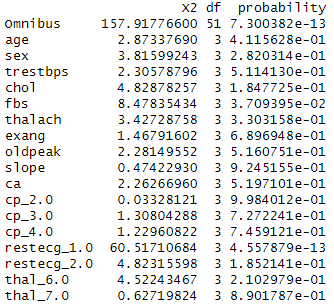*

#### Identification of Non-Proportional Covariates
The diagnostic matrix uncovered a highly informative statistical dynamic:
1. **The Compliant Predictors**: 15 out of 17 clinical covariates (including `age`, `sex`, `ca`, and `cp_4.0`) exhibited high $p$-values ($p > 0.18$), strictly conforming to the parallel lines assumption. Their log-odds impacts remain uniform across all severity thresholds.
2. **The Non-Proportional Covariates**: The global test (**Omnibus** $p < 0.001$) rejected the null hypothesis. A granular scan reveals this structural violation is entirely driven by **`restecg_1.0`** ($p < 0.001$) and mildly by **`fbs`** ($p = 0.037$). Clinically, this indicates that the prognostic hazard of an abnormal ST-T wave dynamically shifts as patient risk escalates from mild to severe, rather than remaining constant.

---

#### Engineering Justification: Why We Retain the Global Proportional Odds Model in Python

Theoretically, a **Partial Proportional Odds Model** would be optimal here to relax constraints exclusively for the violating features (`restecg_1.0` and `fbs`). However, Python's `statsmodels.OrderedModel` currently does not natively support partial proportional odds configurations or specific variable-level parallel constraint relaxations.

Therefore, due to these core package limitations in Python, we retain the original full **Proportional Odds Model** configuration for the subsequent regression estimation and code execution.


In [12]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

# reuse train split from model1
X_train_o = X_train.astype(float)
y_train_o = df.loc[X_train.index, "num"].astype(int)

# Proportional Odds Model
model2 = OrderedModel(
    y_train_o,
    X_train_o,
    distr='logit' #use proper link.
)

res_model2 = model2.fit(method='bfgs', disp=False)

print(res_model2.summary())

                             OrderedModel Results                             
Dep. Variable:                    num   Log-Likelihood:                -178.68
Model:                   OrderedModel   AIC:                             399.4
Method:            Maximum Likelihood   BIC:                             469.9
Date:                Tue, 26 May 2026                                         
Time:                        10:28:57                                         
No. Observations:                 212                                         
Df Residuals:                     191                                         
Df Model:                          17                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
age             0.1173      0.201      0.585      0.559      -0.276       0.510
sex             1.2645      0.455      2.778     

## 4. Clinical Feature Selection via SHAP and Model Refinement

To improve model interpretability and reduce dimensionality, a surrogate logistic regression model (model_tem) was first trained to ensure compatibility with SHAP analysis.

SHAP values were computed to quantify the global contribution of each feature. For categorical variables encoded using one-hot encoding, SHAP values were aggregated back to their original clinical feature groups.

Features were then ranked according to their cumulative SHAP importance, and a subset of features covering approximately 85% of total importance was selected.

Finally, a refined statistical model (model3) was retrained using the selected features within the original statsmodels framework to ensure interpretability and statistical validity.

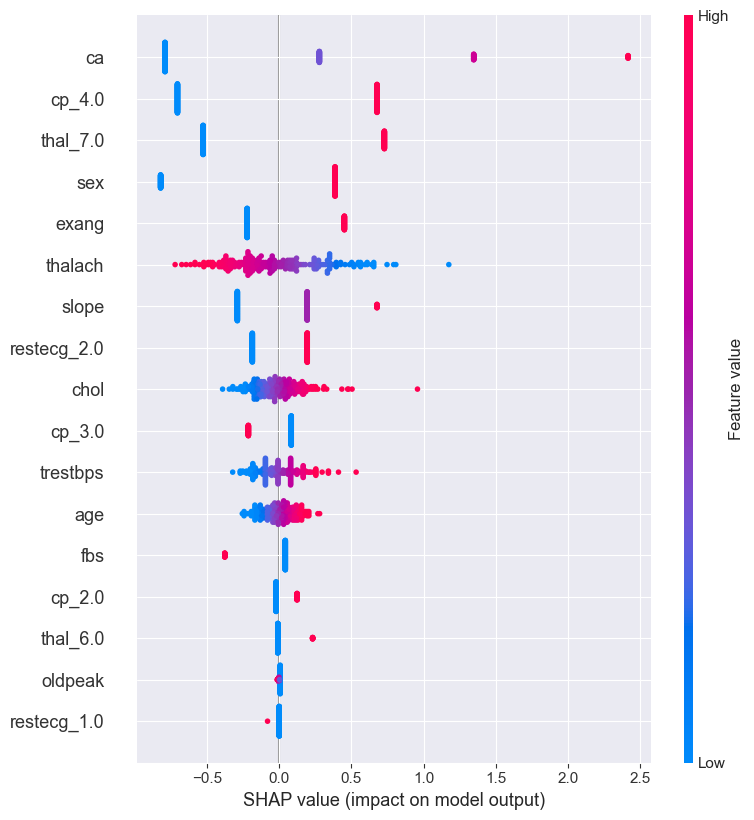

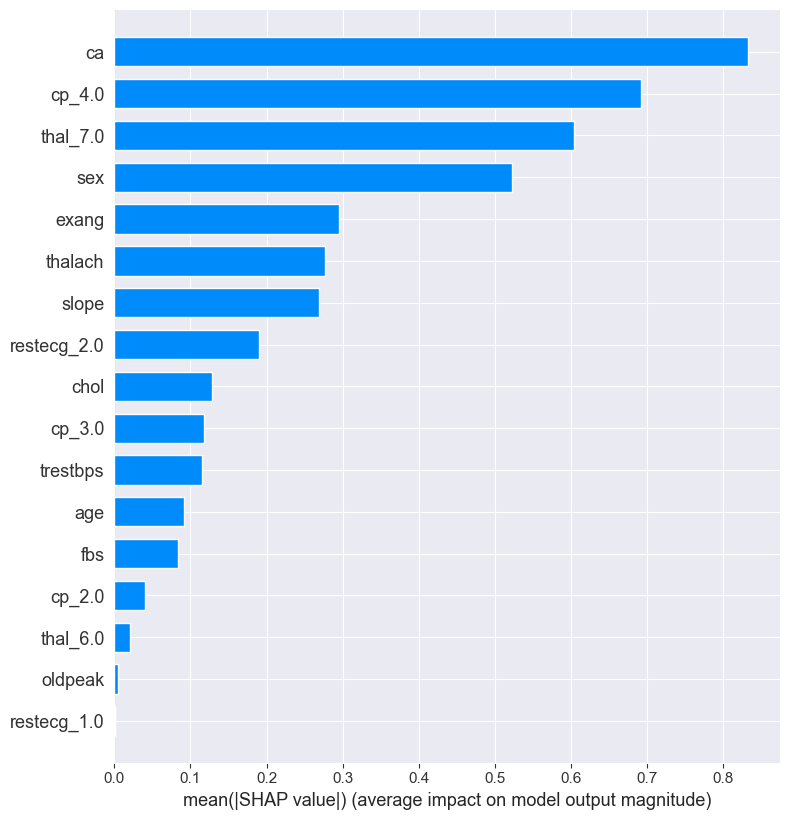

In [13]:
import pandas as pd
import numpy as np
import shap
from sklearn.linear_model import LogisticRegression

# -----------------------------------
# Step 1: Train surrogate model (model_tem)
# -----------------------------------

X = X_train.astype(float)
y = y_train.astype(int)

model_tem = LogisticRegression(max_iter=1000)
model_tem.fit(X, y)

# -----------------------------------
# Step 2: SHAP analysis
# -----------------------------------

explainer = shap.LinearExplainer(model_tem, X)
shap_values = explainer(X)

# global importance
shap_importance = np.abs(shap_values.values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": X.columns,
    "importance": shap_importance
}).sort_values(by="importance", ascending=False)

# SHAP summary plot
shap.summary_plot(shap_values, X)

# bar plot (global importance)
shap.summary_plot(shap_values, X, plot_type="bar")

In [14]:
# -----------------------------------
# Step 3: Merge one-hot encoded features
# -----------------------------------

feature_groups = {
    "cp": [c for c in X.columns if "cp_" in c],
    "thal": [c for c in X.columns if "thal_" in c],
    "restecg": [c for c in X.columns if "restecg_" in c],
    "slope": [c for c in X.columns if "slope_" in c]
}

group_importance = {}

for group, cols in feature_groups.items():
    group_importance[group] = shap_df[
        shap_df["feature"].isin(cols)
    ]["importance"].sum()

# add non-one-hot features
for col in X.columns:
    if not any(col in v for v in feature_groups.values()):
        group_importance[col] = shap_df[
            shap_df["feature"] == col
        ]["importance"].values[0]

group_df = pd.DataFrame.from_dict(
    group_importance,
    orient="index",
    columns=["importance"]
).sort_values(by="importance", ascending=False)

print(group_df)

# -----------------------------------
# Step 4: Select top 85% features
# -----------------------------------

group_df["cum_sum"] = group_df["importance"].cumsum()
group_df["cum_ratio"] = group_df["cum_sum"] / group_df["importance"].sum()

selected_features = group_df[group_df["cum_ratio"] <= 0.85].index.tolist()

print("Selected features (85% SHAP coverage):")
print(selected_features)

          importance
cp          0.850101
ca          0.832975
thal        0.624527
sex         0.522250
exang       0.295782
thalach     0.276324
slope       0.269325
restecg     0.190765
chol        0.127869
trestbps    0.115683
age         0.092041
fbs         0.083030
oldpeak     0.004645
Selected features (85% SHAP coverage):
['cp', 'ca', 'thal', 'sex', 'exang', 'thalach']


In [15]:
import statsmodels.api as sm


feature_map = {
    "cp": [c for c in X_train.columns if "cp_" in c],
    "thal": [c for c in X_train.columns if "thal_" in c],
    "restecg": [c for c in X_train.columns if "restecg_" in c],
    "slope": [c for c in X_train.columns if "slope_" in c]
}


final_features = []

for f in selected_features:
    if f in feature_map:
        final_features.extend(feature_map[f])  # expand one-hot group
    else:
        final_features.append(f)  # numeric feature

# -----------------------------------
# Step 5: Model3 (statistical refit)
# -----------------------------------


X_model3 = X_train[final_features]
X_model3_const = sm.add_constant(X_model3)

model3 = sm.GLM(
    y_train,
    X_model3_const,
    family=sm.families.Binomial(link=sm.families.links.Logit())
)

res_model3 = model3.fit()

print(res_model3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          target_binary   No. Observations:                  212
Model:                            GLM   Df Residuals:                      202
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -75.016
Date:                Tue, 26 May 2026   Deviance:                       150.03
Time:                        10:29:25   Pearson chi2:                     311.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4890
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.5369      0.825     -4.286      0.0

## 5. Model Comparison and Performance Evaluation

To evaluate the trade-off between interpretability and predictive performance, we introduce XGBoost as a benchmark model alongside logistic regression models.

Three models are compared on the held-out test set:
- Model 1: Full-feature logistic regression (IRLS-based GLM)
- Model 3: SHAP-selected feature logistic regression
- XGBoost: Gradient boosting decision tree model

Performance is evaluated using:
- Confusion matrix
- ROC-AUC
- Precision-Recall AUC (AUPRC), with special emphasis on class imbalance sensitivity

This comparison highlights the balance between clinical interpretability and predictive accuracy.

In [16]:
from xgboost import XGBClassifier

# -----------------------------------
# XGBoost baseline model
# -----------------------------------

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

=== Confusion Matrix: Logistic Regression (Model 1) ===
[[43  6]
 [10 32]]

=== Confusion Matrix: Logistic Regression (Model 3) ===
[[41  8]
 [ 8 34]]

=== Confusion Matrix: XGBoost ===
[[41  8]
 [ 8 34]]

=== Final Performance Comparison ===
                                     Accuracy  Precision  Recall  Specificity  \
Logistic Regression (Full)             0.8242     0.8421  0.7619       0.8776   
Logistic Regression (SHAP-selected)    0.8242     0.8095  0.8095       0.8367   
XGBoost                                0.8242     0.8095  0.8095       0.8367   

                                     F1-score     AUC   AUPRC  
Logistic Regression (Full)             0.8000  0.8503  0.8731  
Logistic Regression (SHAP-selected)    0.8095  0.9086  0.9053  
XGBoost                                0.8095  0.9125  0.9092  


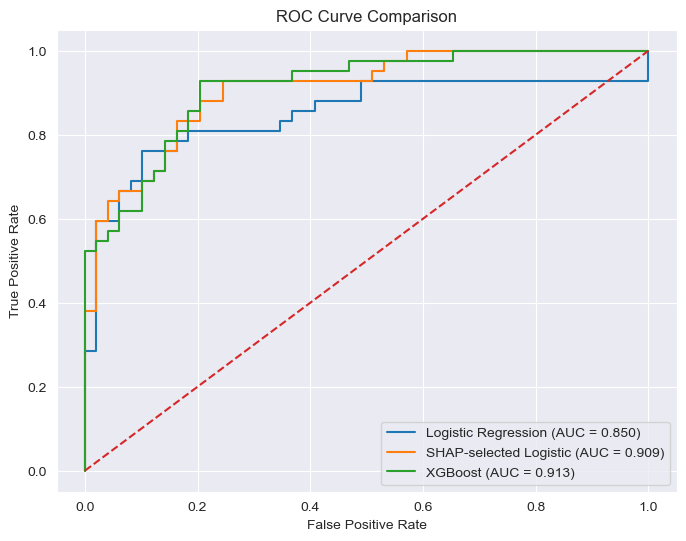

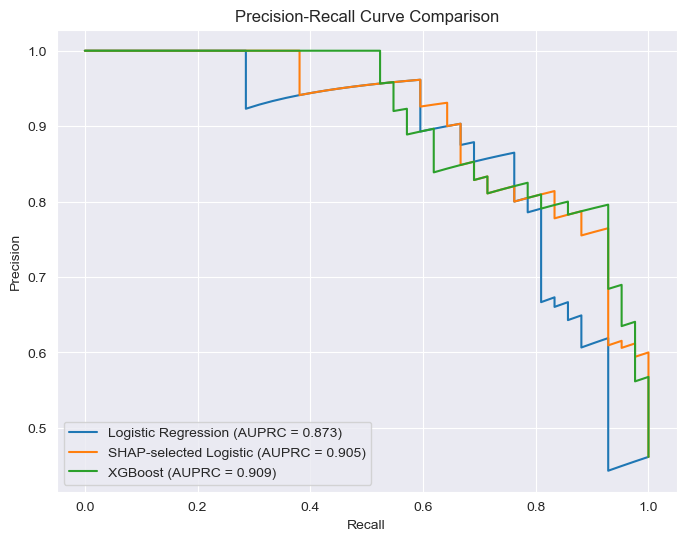

In [17]:
# -----------------------------------
# Model Performance Evaluation
# -----------------------------------

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

# -----------------------------------
# Prepare test matrices
# -----------------------------------

# Model 1 test matrix
X_test_const = sm.add_constant(X_test)

# Model 3 test matrix
X_test_m3 = sm.add_constant(
    X_test[final_features]
)

# -----------------------------------
# Predicted probabilities
# -----------------------------------

# Logistic Regression (Model 1)
y_prob_lr = fit_result.predict(X_test_const)

# XGBoost
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Logistic Regression (Model 3)
y_prob_model3 = res_model3.predict(X_test_m3)

# -----------------------------------
# Binary predictions (threshold = 0.5)
# -----------------------------------

y_pred_lr = (y_prob_lr >= 0.5).astype(int)
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)
y_pred_m3 = (y_prob_model3 >= 0.5).astype(int)

# -----------------------------------
# Confusion Matrices
# -----------------------------------

print("=== Confusion Matrix: Logistic Regression (Model 1) ===")
print(confusion_matrix(y_test, y_pred_lr))
print()

print("=== Confusion Matrix: Logistic Regression (Model 3) ===")
print(confusion_matrix(y_test, y_pred_m3))
print()

print("=== Confusion Matrix: XGBoost ===")
print(confusion_matrix(y_test, y_pred_xgb))
print()

# -----------------------------------
# Evaluation Function
# -----------------------------------

def evaluate_model(y_true, y_pred, y_prob):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": specificity,
        "F1-score": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "AUPRC": average_precision_score(y_true, y_prob)
    }

# -----------------------------------
# Evaluate Models
# -----------------------------------

metrics_lr = evaluate_model(
    y_test,
    y_pred_lr,
    y_prob_lr
)

metrics_m3 = evaluate_model(
    y_test,
    y_pred_m3,
    y_prob_model3
)

metrics_xgb = evaluate_model(
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

# -----------------------------------
# Final Comparison Table
# -----------------------------------

results = pd.DataFrame(
    [metrics_lr, metrics_m3, metrics_xgb],
    index=[
        "Logistic Regression (Full)",
        "Logistic Regression (SHAP-selected)",
        "XGBoost"
    ]
)

print("=== Final Performance Comparison ===")
print(results.round(4))

# -----------------------------------
# ROC Curves
# -----------------------------------

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_m3, tpr_m3, _ = roc_curve(
    y_test,
    y_prob_model3
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {metrics_lr['AUC']:.3f})"
)

plt.plot(
    fpr_m3,
    tpr_m3,
    label=f"SHAP-selected Logistic (AUC = {metrics_m3['AUC']:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {metrics_xgb['AUC']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

# -----------------------------------
# Precision-Recall Curves
# -----------------------------------

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    y_prob_lr
)

precision_m3, recall_m3, _ = precision_recall_curve(
    y_test,
    y_prob_model3
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (AUPRC = {metrics_lr['AUPRC']:.3f})"
)

plt.plot(
    recall_m3,
    precision_m3,
    label=f"SHAP-selected Logistic (AUPRC = {metrics_m3['AUPRC']:.3f})"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (AUPRC = {metrics_xgb['AUPRC']:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()

## 6. Clinical Web-based Decision Support System

To further improve the clinical applicability of the proposed framework, a lightweight interactive web application will be developed based on Streamlit. The system allows clinicians or users to input patient examination indicators and obtain real-time heart disease risk predictions.

Main functionalities include:

- **Interactive Input Module**
  - Users can input patient characteristics through sliders, number boxes, and dropdown menus.
  - Only the SHAP-selected core clinical features are required, reducing operational complexity.

- **Real-time Risk Prediction**
  - The backend loads the simplified logistic regression model.
  - The system outputs the predicted probability of heart disease in real time.

- **SHAP Explainability Visualization**
  - SHAP force plots and bar plots are embedded into the webpage.
  - The system dynamically explains which clinical indicators increase or decrease the predicted risk.

- **Clinical Recommendation Module**
  - Based on the patient’s risk profile and key abnormal indicators, the system automatically generates interpretable clinical suggestions consistent with cardiology knowledge.

- **Online Deployment**
  - The application can be deployed to Streamlit Cloud, allowing external users to access the system through a public URL without requiring local installation.

In [18]:
# -----------------------------------
# Retrain deployable logistic model
# -----------------------------------

from sklearn.linear_model import LogisticRegression
import joblib

# final_features obtained from SHAP selection
print(final_features)

# Training data
X_train_web = X_train[final_features]
X_test_web = X_test[final_features]

# sklearn logistic regression
model_web = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

model_web.fit(X_train_web, y_train)

# Save model
joblib.dump(model_web, "heart_model3.pkl")

print("Web deployment model saved.")

# Save background dataset
X_train_web.to_csv("background_data.csv", index=False)

['cp_2.0', 'cp_3.0', 'cp_4.0', 'ca', 'thal_6.0', 'thal_7.0', 'sex', 'exang', 'thalach']
Web deployment model saved.


## 🚀 Categorical Data Analysis Project: Online Interactive Prediction System Deployment

To transform the heart disease prediction model developed in this study into a practical clinical decision-support tool, we constructed and deployed a 24/7 web-based interactive prediction system leveraging **Streamlit** and **SHAP** frameworks. This marks the full-stack transition of our work from offline statistical data analysis to an online Clinical AI application.

### 🔗 Online System Access Link
👉 **[Heart Disease Risk Prediction System](https://categorical-heartdisease-prediction-8abevlj7ysft4gkzerqom4.streamlit.app/)**

### 🛠️ Key Architecture Design & Engineering Optimizations

1. **Multi-Dimensional Clinical Feature Input**:
   The frontend user interface provides intuitive UI components such as sliders and dropdown menus, allowing clinicians or researchers to input real-time patient clinical features (e.g., Maximum Heart Rate `thalach`, Chest Pain Type `cp`, and Number of Major Vessels `ca`).

2. **Explainable AI (XAI) Implementation**:
   Upon clicking the prediction trigger, the cloud server dynamically computes the SHAP values using `shap.TreeExplainer` and renders two patient-specific interpretability charts:
   - **Global Decision Push (Force Plot)**: Visualizes how individual clinical variables collectively push the baseline probability towards the final risk estimate.
   - **Local Feature Contribution (Bar Plot)**: Renders a sorted magnitude chart of feature impacts, utilizing color codes (Blue for protective factors reducing risk, Red for risk factors escalating risk) for intuitive clinical inspection.

3. **Risk-Stratified Clinical Decision Support**:
   Based on the predicted risk probability, patients are immediately stratified into risk tiers (Low risk $\le 30\%$, Moderate risk, High risk $\ge 70\%$). Combined with specific high-risk indicators (e.g., presence of exercise-induced angina `exang=1` or multi-vessel involvement `ca \ge 2`), the system dynamically generates structured, tailored medical recommendations to assist primary care diagnostic workflows.

***
📖 **For more detailed information, source code, and model training steps, please refer to our GitHub repository:** 👉 [BryceMa1018/categorical-heart_disease-prediction](https://github.com/BryceMa1018/categorical-heart_disease-prediction.git)
***
